# Type Ia supernovae and data analysis

## Python syntax

* Indentations are mandatory in Python
* Common mathematical operations are :
    + `+,-,*,/` and `**`
    + can be combined with `=` for instance to increment a variable `i += 1`
* Numpy library contains a lot of useful mathematical functions such as :
    + `np.sqrt(  )`, `np.exp(   )`, `np.log(  )`, `np.log10(   )` 
    + statistics of an array : `np.mean(  )`, `np.std(   )`
    + sum of array elements : `np.sum(   )`

## Magnitudes and standard candles

The magnitude is a logarithmic scale that measures the brightness of an object observed from Earth. It is based on the measurement of flux $F_{\rm obs}$ measured with a telescope and compared with a reference flux $F_{\rm ref}$ that fixes the scale. The latter generally relies on a standard star, Vega in the Lyra constellation. The notion of magnitude is linked to the spectral bandwidth of the instrument.

The brightness of an object can be expressed in terms of its absolute magnitude. This quantity is derived from the logarithm of its luminosity $L$ as seen from a distance of $10\,$parsecs.

The apparent magnitude $m_B(z)$ in the filter $f$, or the magnitude as seen by the observer, is defined for historical reasons as:
\begin{equation}
m_f(z) = -2.5\log_{10} \left[\frac{\Phi_{\rm obs}}{\Phi_{\rm ref}} \right]
\end{equation}


The absolute magnitude $m_B(z)$ in the filter $B$, or the magnitude as seen by the observer, is defined for historical reasons as:
\begin{equation}
M_B = -2.5 \log_{10} \frac{\Phi_{\rm obs}(10\,\mathrm{pc})}{\Phi_{\rm ref}} =  -2.5 \log_{10} \frac{L}{4\pi (10\,\mathrm{pc})^2 \Phi_{\rm ref}}
\end{equation}

\begin{align*}
m_f(z) & = -2.5\log_{10} \left[\frac{\Phi_{\rm obs}}{\Phi_{\rm ref}} \right] =  5 \log_{10} \frac{D_L(z)}{10\,\mathrm{pc}}  + M_B  + K_{fB} \\
\end{align*}

We define the B-band rest-frame magnitude as:
\begin{align*}
m_B^* = m_f - K_{fB}
\end{align*}
and the luminosity distance:
\begin{equation}
D_L(z) =  \left\lbrace\begin{array}{cl}
    \displaystyle{\frac{(1+z)c}{H_0\sqrt{-\Omega_k^0}}\sin\left[H_0\sqrt{-\Omega_k^0}\int_0^z\frac{dz}{H(z)}\right]}  & \text{ if } k=+1 \\
    \displaystyle{(1+z)\int_0^z\frac{cdz}{H(z)}} & \text{ if } k=0 \\
    \displaystyle{\frac{(1+z)c}{H_0\sqrt{\Omega_k^0}}\sinh\left[H_0\sqrt{\Omega_k^0}\int_0^z\frac{dz}{H(z)}\right] }  & \text{ if } k=-1
\end{array}
\right.
\end{equation}

We give $M_B = -19.08$ mag.

## A simple Hubble diagram


In the joined data file, the most recent type Ia supernovae measurements from SNLS collaboration have been reported Betoule et al. 2014. 740 good quality supernovae are present with their name, their redshift $z$ (`zcmb`) and their rest-frame $B$ band peak magnitude $m_B^*$ (`mb`) with its uncertainty $\delta m_B^*$ (`dmb`). The column `set` gives a label for each data set among SNLS, low-z, SDSSS and HST. They are sorted by redshift in ascending order. See Figure 8 in https://arxiv.org/abs/1401.4064 .

**First, initialize the notebook and make the plot $m_B^*(z)$ so as it looks like the one in quoted figure above.**

In [3]:
# initialisation of the notebook
import numpy as np
import matplotlib.pylab as plt
import pandas as pd
import astropy.units as u

%matplotlib ipympl

In [4]:
# import data
df = pd.read_csv("data/sne_data_zsorted.txt", delimiter="\t")
df

,#name,zcmb,zhel,dz,mb,dmb,x1,dx1,color,dcolor,3rdvar,d3rdvar,cov_m_s,cov_m_c,cov_s_c,set,mb_corr
0,sn1999ac,0.010060,0.009500,0.000236,14.148421,0.174566,0.202688,0.068440,0.048593,0.025981,9.917000,0.128500,0.000244,0.000652,-0.000154,3,14.05227
1,sn2004s,0.010291,0.009370,0.000428,14.157498,0.173593,-0.117402,0.082511,0.022258,0.024846,9.708903,0.280891,-0.000483,0.000665,-0.000348,3,14.08718
2,sn1997do,0.010550,0.010120,0.000077,14.449314,0.173090,0.791332,0.187870,0.118415,0.030547,9.941915,0.280891,0.003521,0.000989,0.001322,3,14.25219
3,sn2002dp,0.010888,0.011638,0.000448,14.557203,0.169021,-0.316464,0.184325,0.054095,0.023005,10.470000,0.363500,0.001596,0.000487,0.001020,3,14.38241
4,sn2006bh,0.011184,0.010900,0.000634,14.342973,0.166533,-1.648794,0.032216,-0.083155,0.019407,10.915000,0.352000,-0.000039,0.000286,-0.000115,3,14.34476
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
735,06D3en,1.060801,1.060000,0.000000,24.707870,0.132013,-0.952679,0.412773,-0.158207,0.061030,7.715000,0.935000,0.010444,-0.003050,0.004456,1,24.98430
736,Gabi,1.120850,1.120000,0.000000,25.147113,0.121686,0.620453,0.307485,-0.075491,0.053200,8.335000,0.296000,0.004032,0.000388,0.005988,4,25.41340
737,Lancaster,1.230892,1.230000,0.000000,26.046776,0.128558,-0.077374,0.690464,0.087011,0.048271,10.134000,0.194500,0.003542,0.000211,0.008241,4,25.81958
738,Torngasek,1.265901,1.265000,0.000000,25.735598,0.128614,0.286816,0.559546,0.021062,0.047718,10.834000,0.391000,-0.003817,-0.000169,0.003064,4,25.71880


**Define a function `mB_f(z, OmegaM, OmegaL, MB)` that returns an array of distance modules $\mu(z)+M_B$ given an array of redshifts `z`, and values for $\Omega_m^0$, $\Omega_\Lambda^0$ and $M_B$.** 

**Hints:**
- Use the [astropy.cosmology](https://docs.astropy.org/en/stable/cosmology/) library to set a `LambdaCDM` cosmology with common values for cosmological parameters and get the luminosity distance. 
- If needed, to set a `Quantity` of 1 parcec, use `1e-6 * u.megaparsec` thanks to [astropy.units](https://docs.astropy.org/en/stable/units/).
- To set quantities in magnitude use `u.mag`.

In [5]:
from astropy.cosmology import LambdaCDM
from scipy.integrate import quad

Om0=0.3
Ode0=0.7
M_B = -19.08

def mB_f_func(z, Om0, Ode0, M_B, H0=70):
    cosmo = LambdaCDM(H0=H0, Om0=Om0, Ode0=Ode0)
    DL = cosmo.luminosity_distance(z)
    mu = 5 * np.log10( DL / (10 * u.pc))
    return mu + M_B

z = df["zcmb"]
mB_f = mB_f_func(z, Om0 = Om0, Ode0 = Ode0, M_B = M_B)

**Superimpose your prediction for $m^*_{B}$ on the Hubble diagram. Be curious and test other parameters to see the curve shape evolving.**

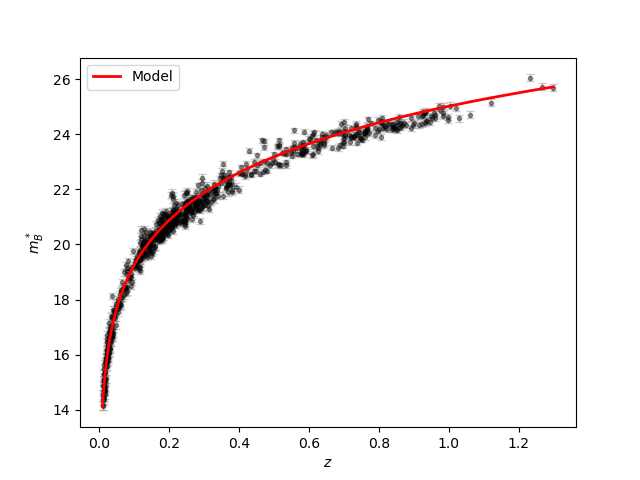

In [6]:
fig, ax = plt.subplots()

ax.plot(z, mB_f, color="red", lw=2, label="Model")

ax.errorbar(
    df["zcmb"],
    df["mb"],
    yerr=df["dmb"],
    fmt='.',
    alpha=0.4,
    color='black',
    ecolor='gray',      
    elinewidth=1,       
    capsize=3,          
    capthick=1,         
    zorder=1            # make sure points are below the line
)

ax.set_xlabel("$z$")
ax.set_ylabel("$m_B^*$")
ax.legend()

plt.show()

**Use the `scipy.optimize` function [curve_fit](https://docs.scipy.org/doc/scipy/reference/generated/scipy.optimize.curve_fit.html) to adjust your model to data. Include the uncertainties in the fit using `absolute_sigma=True`.**

In [7]:
from scipy.optimize import curve_fit

popt, pcov = curve_fit(
    lambda z, Om0, Ode0, M_B: mB_f_func(z, Om0, Ode0, M_B, H0=70),
    z, df["mb"], sigma=df["dmb"], absolute_sigma=True, p0=[Om0, Ode0, M_B])

**To check the quality of the fit, compute the array of residuals of your best-fit model and plot them as a function of redshift. Then compute the RMS of the residuals, the total $\chi^2$ and the reduced $\chi^2$.**

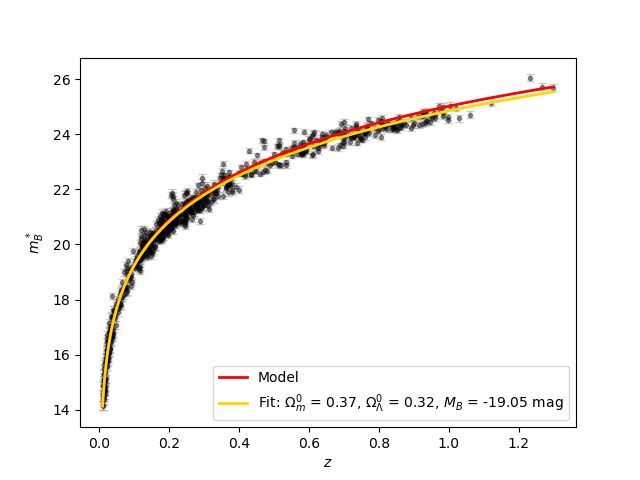

In [8]:
plt.figure()

plt.plot(z, mB_f, color="red", lw=2, label="Model")

mB_fit = mB_f_func(z, *popt)
plt.plot(z, mB_fit , color="gold", lw=2, label=f"Fit: $\Omega_m^0$ = {popt[0]:.2f}, $\Omega_\Lambda^0$ = {popt[1]:.2f}, $M_B$ = {popt[2]:.2f} mag")

plt.errorbar(
    df["zcmb"],
    df["mb"],
    yerr=df["dmb"],
    fmt='.',
    alpha=0.4,
    color='black',
    ecolor='gray',      
    elinewidth=1,       
    capsize=3,          
    capthick=1,         
    zorder=1            # make sure points are below the line
)

plt.xlabel("$z$")
plt.ylabel("$m_B^*$")
plt.legend()

plt.show()

In [9]:
residuals = df["mb"] - mB_fit
rms = np.sqrt(np.mean(residuals**2))

chi2 = np.sum((residuals / df["dmb"])**2)

dof = len(df["mb"]) - len(popt)  # degrees of freedom
chi2_reduced = chi2 / dof

print(f"RMS = {rms:.4f}")
print(f"chi2 = {chi2:.4f}")
print(f"Reduced chi2 = {chi2_reduced:.4f}")

RMS = 0.2806
chi2 = 4578.5913
Reduced chi2 = 6.2125


**Comment the value of `total_chisq` and `RMS`.**

The total value of `total_chisq` is huge compared to 740 : it means that the fit is bad even for a good-looking fit on the plot. This is because the spread of data around the model is statistically larger than the magnitude uncertainties: `RMS` is around 0.3 mag. There is an additional magnitude variability in the SN data set that is not accounted yet.

**Check that changing the $H_0$ value does not modify the best fit cosmological parameters but only the constant $M_B$.**

In [10]:
popt1, pcov1 = curve_fit(
    lambda z, Om0, Ode0, M_B: mB_f_func(z, Om0, Ode0, M_B, H0=68),
    z, df["mb"], sigma=df["dmb"], absolute_sigma=True
)

In [11]:
popt

array([  0.37479612,   0.32221469, -19.05027481])

In [12]:
popt1

array([  0.37481525,   0.32224246, -19.11322181])

## Corrected magnitudes

Actually, the type Ia supernovae are not so standard but standarisable. They have a supplementary variability that depends on their color and their duration ([arXiv:astro-ph/0510447 ](https://arxiv.org/pdf/astro-ph/0510447)). For instance, the longer is the supernovae the brighter it is also (the *brighter-slower* rule). These systematic bias can be removed to increase the quality of the data sample.

In the data file, the `color` column gives the $B-V$ color and the "stretch" parameter `x1` measures the duration of the supernova. They are given with their uncertainties.



**First, make a scatter plot of your best-fit residuals versus `color`, with all the uncertainties. Then, fit the residuals with a line: $m_B^*-\texttt{mb} \,\equiv\,  \beta\, \texttt{color} + C$ (you can use [numpy.polyfit](https://numpy.org/doc/stable/reference/generated/numpy.polyfit.html)). Plot the best fit line and comment on how to correct your magnitude model.**

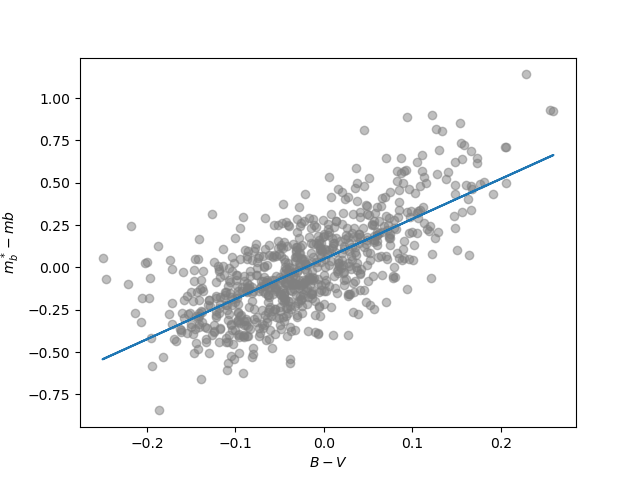

In [13]:
plt.figure()

color = df["color"]
plt.scatter(color, residuals, color="gray", alpha=0.5)

color_fit_coef = np.polyfit(color, residuals, 1)
color_fit = np.poly1d(color_fit_coef)
plt.plot(color, color_fit(color))

plt.xlabel("$B-V$")
plt.ylabel("$m_b^* - mb$")

plt.show()

**Then, make a scatter plot of your best-fit residuals versus `x1`, with all the uncertainties. Fit the residuals with a line: $m_B^*-\texttt{mb}\, \equiv \,  \alpha\, \texttt{x1} + C$. Plot the best fit line and comment on how to correct your magnitude model.**

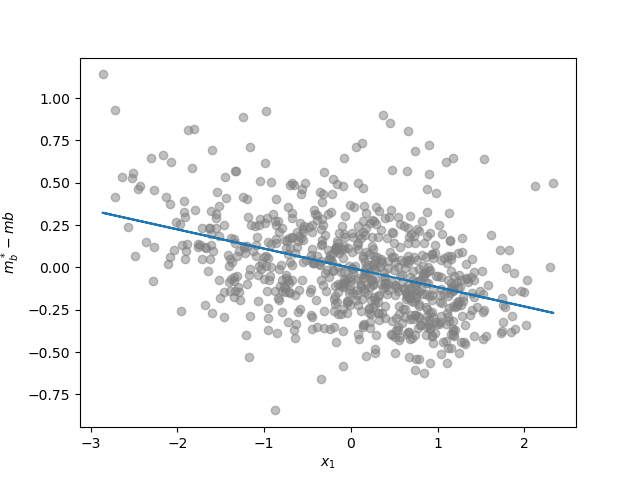

In [14]:
plt.figure()

x1 = df["x1"]
plt.scatter(x1, residuals, color="gray", alpha=0.5)

x1_fit_coef = np.polyfit(x1, residuals, 1)
x1_fit = np.poly1d(x1_fit_coef)
plt.plot(x1, x1_fit(x1))

plt.xlabel("$x_1$")
plt.ylabel("$m_b^* - mb$")

plt.show()

**Propose a way to correct the measured magnitudes in order to remove the systematic trends that we observe. Fill an array `mb_corr` with your proposition, and a array `mb_corr_err` with the propagated uncertainties.**

In [15]:
alpha = x1_fit_coef[0]
beta = color_fit_coef[0]

mb_corr = mB_fit - alpha * x1 - beta * color

mb_corr_err = np.sqrt(df["dmb"]**2 + (alpha * df["dx1"])**2 + (beta * df["dcolor"])**2)

**Make a new Hubble diagram using these corrected magnitudes and superimpose your cosmological model. Compute again the residuals and $\chi^2$ as previously for this new fit. Comment.**

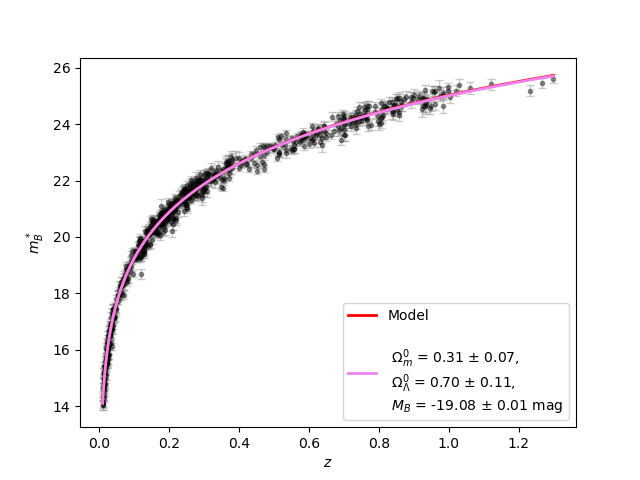

In [16]:
plt.figure()

plt.plot(z, mB_f, color="red", lw=2, label="Model")

popt_corr, pcov_corr = curve_fit(
    lambda z, Om0, Ode0, M_B: mB_f_func(z, Om0, Ode0, M_B, H0=70),
    z, mb_corr, sigma=mb_corr_err, absolute_sigma=True, p0=[Om0, Ode0, M_B])

mB_corr_fit = mB_f_func(z, *popt_corr)
sigma_mB_corr = np.sqrt(np.diag(pcov_corr))

plt.plot(z, mB_corr_fit , color="violet", lw=2, 
         label=f"\n $\Omega_m^0$ = {popt_corr[0]:.2f} $\pm$ {sigma_mB_corr[0]:.2f}, \n $\Omega_\Lambda^0$ = {popt_corr[1]:.2f} $\pm$ {sigma_mB_corr[1]:.2f}, \n $M_B$ = {popt_corr[2]:.2f} $\pm$ {sigma_mB_corr[2]:.2f} mag")

plt.errorbar(
    z,
    mb_corr,
    yerr=mb_corr_err,
    fmt='.',
    alpha=0.4,
    color='black',
    ecolor='gray',      
    elinewidth=1,       
    capsize=3,          
    capthick=1,         
    zorder=1            # make sure points are below the line
)

plt.xlabel("$z$")
plt.ylabel("$m_B^*$")
plt.legend()

plt.show()

**What are the best fit values for $\Omega_m^0$ and $\Omega_\Lambda^0$ and their uncertainties?**

**Plot the new residuals.**

In [17]:
res_corr = mb_corr - mB_corr_fit

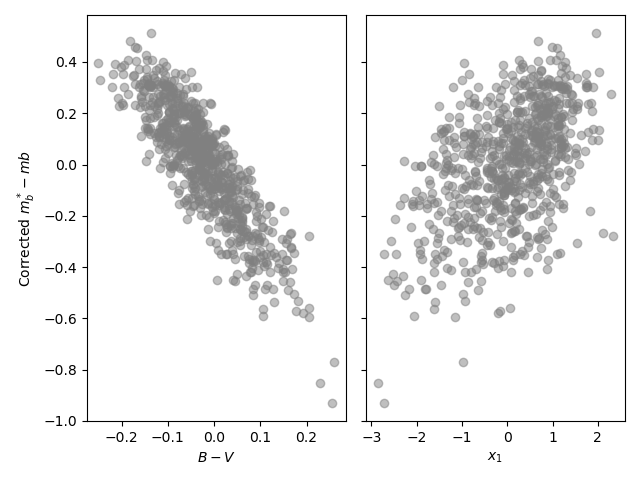

In [18]:
fig, ax = plt.subplots(1, 2, sharey=True)

ax[0].scatter(color, res_corr, color="gray", alpha=0.5)

ax[0].set_xlabel("$B - V$")
ax[0].set_ylabel("Corrected $m_b^* - mb$")

ax[1].scatter(x1, res_corr, color="gray", alpha=0.5)
ax[1].set_xlabel("$x_1$")

plt.tight_layout()
plt.show()

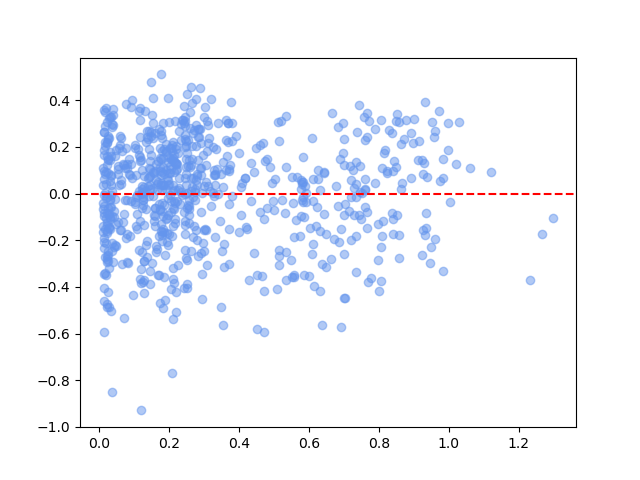

In [19]:
plt.figure()

plt.scatter(z, res_corr, color="cornflowerblue", alpha=0.5)
plt.axhline(0, linestyle="--", color='red')

plt.show()

## Full model

The full model contains the cosmological models but also the nuisance parameters $\alpha$ and $\beta$ that have to be fitted on data together.

**Write a function `chisq_LCDM(Omega_m,Omega_L,alpha,beta,MB)` that returns the total $\chi^2$, using most of the previous code.**


In [20]:
def chisq_LCDM(Om0, Ode0, alpha, beta, MB):
    mb = mB_f_func(df["zcmb"], Om0, Ode0, MB) + alpha * df["x1"] + beta * df["color"]
    sigma_mb = np.sqrt(df["dmb"]**2 + (alpha * df['dx1'])**2 + (beta * df['dcolor'])**2)
    
    res = df["mb"] - mb
    rms = np.sqrt(np.mean(res**2))
    chi2 = np.sum((res / sigma_mb)**2)
    
    dof = len(mb) - 3  # degrees of freedom
    chi2_reduced = chi2 / dof

    return [rms, chi2, chi2_reduced]

**Execute the function with various parameters for $\alpha$, $\beta$, $\mathcal{M}$. Check that you had found the best fitting model.**

In [21]:
delta = 1
delta_M = 1
delta_O = 0.3

Om0_best = popt_corr[0]
Ode0_best = popt_corr[1]
M_B_best = popt_corr[2]
n = 100

alpha_arr = np.linspace(alpha - delta, alpha + delta, n)
beta_arr = np.linspace(beta - delta, beta + delta, n)
M_arr = np.linspace(M_B_best - delta_M, M_B_best + delta_M, n)
Om0_arr = np.linspace(Om0_best - delta_O, Om0_best + delta_O, n)

chisq_arr_alpha = []
chisq_arr_beta = []
chisq_arr_M = []
chisq_arr_Om0 = []

for i in range(n):
    chisq_arr_alpha.append(chisq_LCDM(Om0_best, Ode0_best, alpha_arr[i], beta, M_B_best))
    chisq_arr_beta.append(chisq_LCDM(Om0_best, Ode0_best, alpha, beta_arr[i], M_B_best))
    chisq_arr_M.append(chisq_LCDM(Om0_best, Ode0_best, alpha, beta, M_arr[i]))
    chisq_arr_Om0.append(chisq_LCDM(Om0_arr[i], Ode0_best, alpha, beta, M_B_best))

chisq_arr_alpha = np.array(chisq_arr_alpha)
chisq_arr_beta = np.array(chisq_arr_beta)
chisq_arr_M = np.array(chisq_arr_M)
chisq_arr_Om0 = np.array(chisq_arr_Om0)

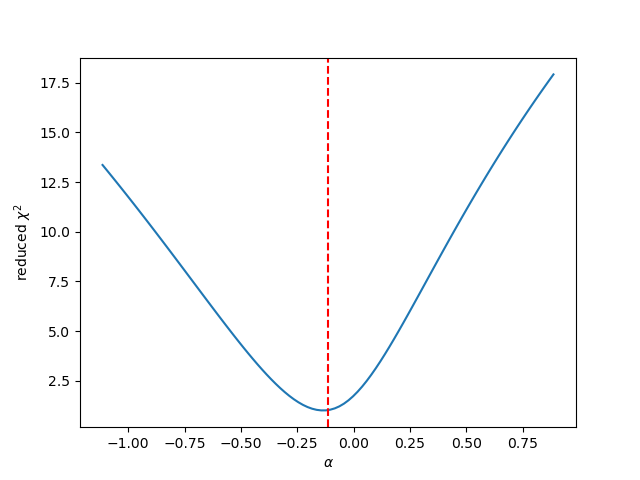

In [22]:
plt.figure()

plt.plot(alpha_arr, chisq_arr_alpha[:,2])
plt.axvline(alpha, linestyle='--', color='red')
plt.xlabel(r"$\alpha$")
plt.ylabel(r"reduced $\chi^2$")
plt.show()

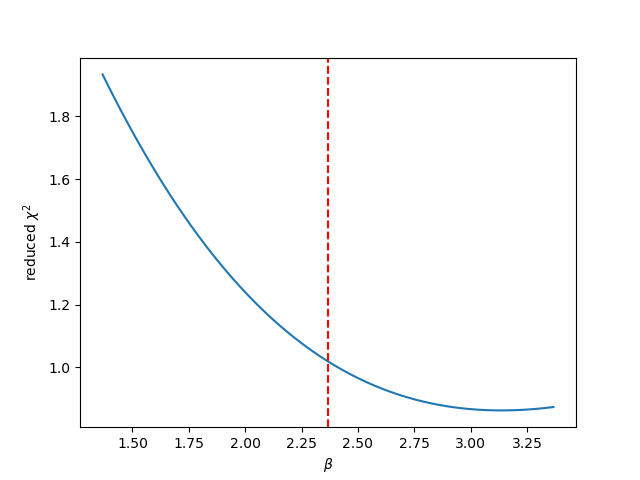

In [23]:
plt.figure()

plt.plot(beta_arr, chisq_arr_beta[:,2])
plt.axvline(beta, linestyle='--', color='red')
plt.xlabel(r"$\beta$")
plt.ylabel(r"reduced $\chi^2$")
plt.show()

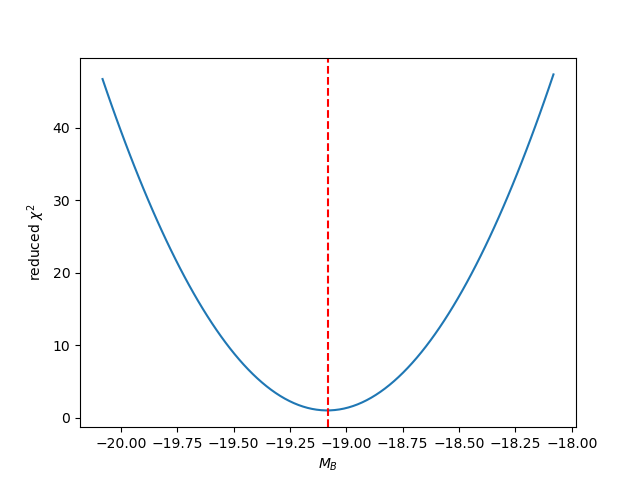

In [24]:
plt.figure()

plt.plot(M_arr, chisq_arr_M[:,2])
plt.axvline(M_B_best, linestyle='--', color='red')
plt.xlabel(r"$M_B$")
plt.ylabel(r"reduced $\chi^2$")
plt.show()

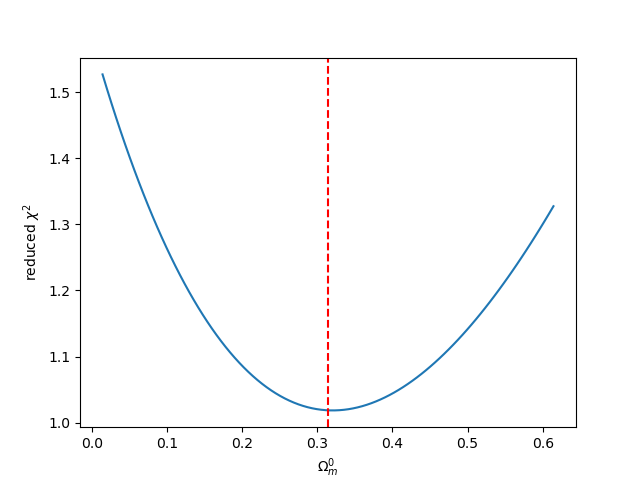

In [25]:
plt.figure()

plt.plot(Om0_arr, chisq_arr_Om0[:,2])
plt.axvline(Om0_best, linestyle='--', color='red')
plt.xlabel(r"$\Omega_m^0$")
plt.ylabel(r"reduced $\chi^2$")
plt.show()

## Testing the flat $\Lambda$CDM model

The goal now is to estimate the best fit parameters of the **flat** $\Lambda$CDM model. This cosmological model has only one free parameter, $\Omega_m^0$, as we have $\Omega_\Lambda^0 = 1 - \Omega_m^0$. Using the supernova data, we want to obtain the probability density function of $\Omega_m^0$ given the observed supernovae magnitudes.

The Bayes theorem gives:
\begin{equation}
\mathrm{PDF}(\Omega_m^0 \vert \mathrm{data}) = \frac{ \mathrm{PDF}(\mathrm{data} \vert \Omega_m^0) \mathrm{PDF}(\Omega_m^0)} { \mathrm{PDF}(\mathrm{data})}
\end{equation}
$\mathrm{PDF}(\mathrm{data})$ and $\mathrm{PDF}(\Omega_m^0)$ corresponds to prior knowledge of the given quantities, which are usually assumed to be flat in cosmology (no information about $\Omega_m^0$ before the fit). The likelihood function is defined as the probability to observe a dataset in a particular model:
\begin{equation}
\mathcal{L}(\Omega_m^0) \equiv  \mathrm{PDF}(\mathrm{data} \vert \Omega_m^0)
\end{equation}
Assuming Gaussian probabilities, this function can be evaluated by:
\begin{equation}
\mathcal{L}(\Omega_m^0)  \propto e^{-\chi^2(\Omega_m^0) / 2}
\end{equation}
Then, the probability density function of $\Omega_m^0$ is the likelihood function normalised to unity. See https://npac.ijclab.in2p3.fr/wp-content/uploads/2024/COURS/Sem1/statistics/NPAC_Statistics_2024_25.pdf 


**Now, for a flat $\Lambda$CDM model, initialize a $\Omega_m^0$ array between 0.25 and 0.4. Compute the corresponding $\Omega_\Lambda^0$ array in the flat case. Then for these sets of parameters, compute and plot the likelihood function $\mathcal{L}(\Omega_m^0)$. What is the best fit value of $\Omega_m^0$ and its uncertainty?**

In [26]:
L_Om0 = np.exp(-chisq_arr_Om0[:,2]/2)

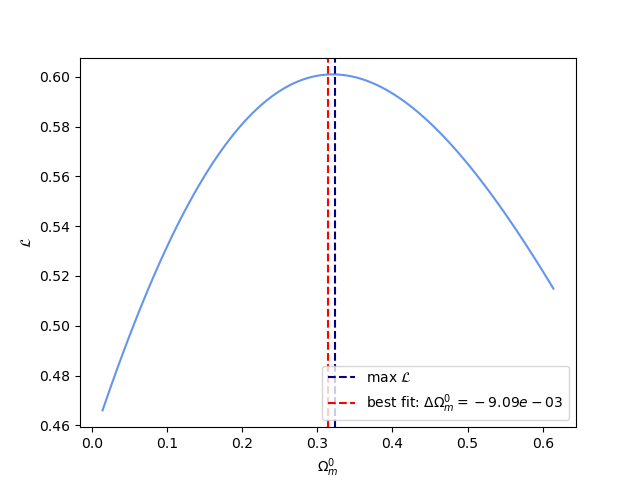

In [27]:
plt.figure()

Om0_maxL = Om0_arr[L_Om0 == L_Om0.max()][0]
plt.plot(Om0_arr, L_Om0, color='cornflowerblue')
plt.axvline(Om0_maxL, color="darkblue", linestyle='--', label=r"max $\mathcal{L}$")
plt.axvline(Om0_best, linestyle='--', color='red', label=fr"best fit: $\Delta \Omega_m^0 = {Om0_best - Om0_maxL:.2e}$")
plt.xlabel(r"$\Omega_m^0$")
plt.ylabel(r"$\mathcal{L}$")

plt.legend()
plt.show()

**Optional: test a matter-only cosmological model with different values of $\Omega_m^0$ and remark that such a model is incompatible with data whatever value for its parameters: you need dark energy!**

# Testing the $\Lambda$CDM model

**Reproduce Figure 14 from https://arxiv.org/abs/1401.4064 , computing the 2D PDF $\mathcal{L}(\Omega_m^0, \Omega_\Lambda^0)$.**


In [28]:
n = 50
Om0_arr = np.linspace(0, .8, n)
Ode0_arr = np.linspace(0, 1, n)

Om0_grid, Ode0_grid = np.meshgrid(Om0_arr, Ode0_arr, indexing='ij')  
re_chisq_arr_Om0_Ode0 = np.zeros((n, n, 3))

for i in range(n):
    for j in range(n):
        re_chisq_arr_Om0_Ode0[i,j] = chisq_LCDM(Om0_arr[i], Ode0_arr[j], alpha, beta, M_B_best)

In [49]:
L_Om0_Ode0 = np.exp(-re_chisq_arr_Om0_Ode0[:,:,1]/2)
delta_chi2 = re_chisq_arr_Om0_Ode0[:,:,1] - np.min(re_chisq_arr_Om0_Ode0[:,:,1])

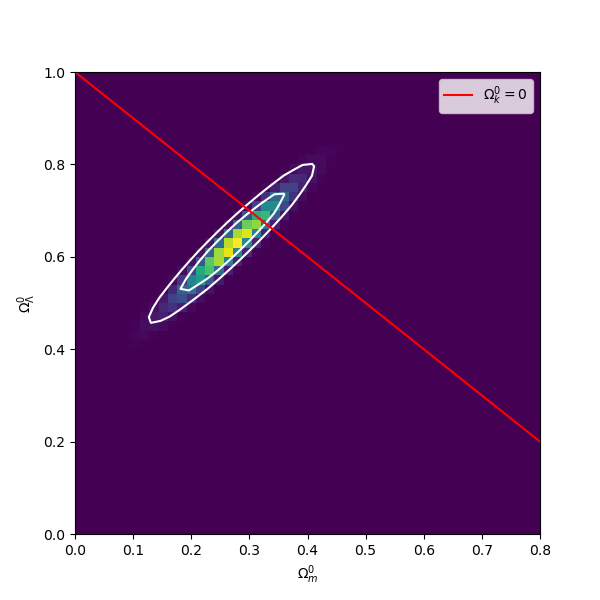

In [56]:
plt.figure(figsize=(6,6))

# imshow
plt.imshow(
    L_Om0_Ode0.T,       # transpose so x=Om0, y=Ode0
    origin='lower',                 # bottom-left is (Om0[0], Ode0[0])
    aspect='auto',
    extent=[Om0_arr[0], Om0_arr[-1], Ode0_arr[0], Ode0_arr[-1]],  # axis limits
    cmap='viridis'
)

# plt.colorbar(label='$\mathcal{L}$')

CS = plt.contour(
    Om0_grid, Ode0_grid, delta_chi2,
    levels=[2.3, 5.99],
    colors="white"
)
# plt.clabel(CS, inline=True, fontsize=8)  # label contours

plt.plot(Om0_arr, 1 - Om0_arr, color='red', label="$\Omega_k^0 = 0$")

plt.xlabel("$\Omega_m^0$")
plt.ylabel("$\Omega_\Lambda^0$")
plt.legend()
plt.show()

**You can add the 68% and 95% probability contours with `matplotlib.contours`. The first one stands where $\Delta \chi^2 = \chi^2(\Omega_m^0, \Omega_\Lambda^0) - min(\chi^2(\Omega_m^0, \Omega_\Lambda^0))$ is 2.3, and the second one for 5.99 (see table 40.2 https://pdg.lbl.gov/2020/reviews/rpp2020-rev-statistics.pdf). Add the line on the plot where $\Omega_k^0 = 0$.**

## Testing flat $w$CDM model

**If you have time, test the flat $w$CDM model, like Figure 15  from https://arxiv.org/abs/1401.4064 .**